# Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing 
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler 

# modelling 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans,AgglomerativeClustering, DBSCAN

# Evaluation 
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import accuracy_score,classification_report, silhouette_score,adjusted_rand_score,normalized_mutual_info_score


In [4]:
df = pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_train.csv')

df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.shape

(60000, 785)

In [6]:
df.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=785)

#  seperating target variable 

In [ ]:
X = df.drop(['label'], axis=1).values
y = df['label'].values

In [8]:
# normalize in the range of [0-1]

X = X/255.0

In [9]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [10]:
y

array([2, 9, 6, ..., 8, 8, 7])

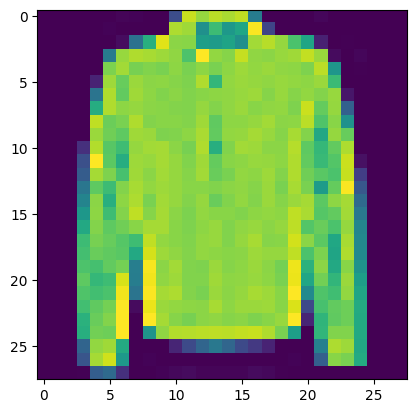

In [18]:
plt.imshow(X[8].reshape(28,28))

In [98]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

# Using KNeighborClassifier 

# KNN without Scalling 

In [99]:

clf= KNeighborsClassifier(n_neighbors=5)

In [101]:
clf.fit(X_train,y_train)

KNeighborsClassifier()

In [102]:
y_pred=clf.predict(X_test)

In [103]:
accuracy_score(y_test,y_pred)

0.8558333333333333

In [104]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.87      0.76      0.81      1411
           1       0.96      0.99      0.98      1143
           2       0.82      0.74      0.78      1327
           3       0.87      0.90      0.88      1211
           4       0.76      0.78      0.77      1164
           5       0.83      0.99      0.91       960
           6       0.56      0.66      0.61      1051
           7       0.96      0.89      0.92      1319
           8       0.95      0.98      0.97      1122
           9       0.97      0.91      0.94      1292

    accuracy                           0.86     12000
   macro avg       0.86      0.86      0.86     12000
weighted avg       0.86      0.86      0.86     12000



# KNN with StandardScaler and PCA 

In [26]:
# We need to do feature scaling first.
# mean =0 , std=1 

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [44]:
# PCA with 50 components 
pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# reduce columns upto 10 column 

In [45]:
print(X_train.shape)
print(X_train_pca.shape)

(48000, 784)
(48000, 50)


In [46]:
clf= KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train_pca,y_train)

KNeighborsClassifier()

In [48]:
y_pred_pca = clf.predict(X_test_pca)


In [49]:
accuracy_score(y_pred_pca,y_test)

0.8499166666666667

In [ ]:
# PCA with different values 

results = {}
    
for n in range(10,100):
    pca = PCA(n_components=n, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
        
    clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
        
    results[n] = acc
    # print(f"PCA components={n}, Accuracy={acc:.4f}")


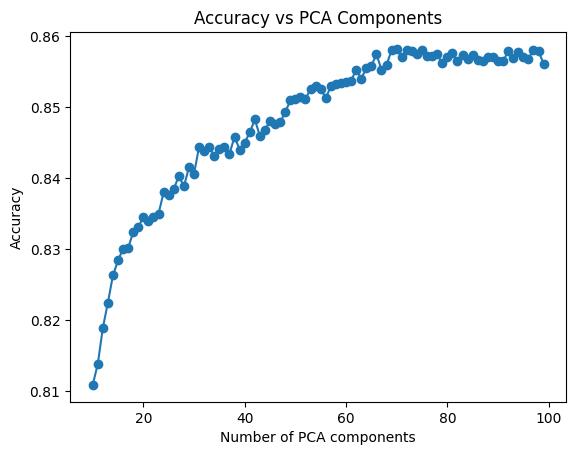

In [33]:
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xlabel("Number of PCA components")
plt.ylabel("Accuracy")
plt.title("Accuracy vs PCA Components")
plt.show()

In [37]:
# We have a best accuracy for pca with 70 components 

0.8581666666666666

In [50]:
# for finding the best value of K 
best_k = None
best_acc = 0
results = {}

#  from 1 to 20 
for k in range(1, 21):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    
    results[k] = acc
    
    print(f"K={k}, Accuracy={acc:.4f}")
    
    if acc > best_acc:
        best_acc = acc
        best_k = k

print(f"\nBest K = {best_k} with Accuracy = {best_acc:.4f}")

K=1, Accuracy=0.8300
K=2, Accuracy=0.8321
K=3, Accuracy=0.8443
K=4, Accuracy=0.8476
K=5, Accuracy=0.8499
K=6, Accuracy=0.8529
K=7, Accuracy=0.8525
K=8, Accuracy=0.8531
K=9, Accuracy=0.8523
K=10, Accuracy=0.8513
K=11, Accuracy=0.8507
K=12, Accuracy=0.8518
K=13, Accuracy=0.8513
K=14, Accuracy=0.8512
K=15, Accuracy=0.8492
K=16, Accuracy=0.8500
K=17, Accuracy=0.8501
K=18, Accuracy=0.8493
K=19, Accuracy=0.8490
K=20, Accuracy=0.8472

Best K = 8 with Accuracy = 0.8531


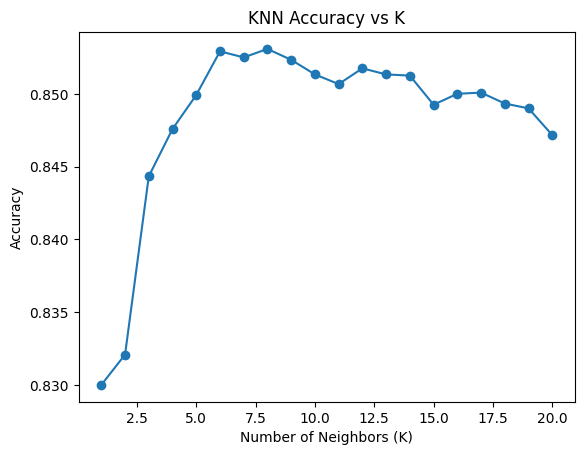

In [51]:
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.show()

In [52]:
# now try out best combination with PCA = 70 components and K=8 neighbor 

pca = PCA(n_components=70, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

clf = KNeighborsClassifier(n_neighbors=8)
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)
acc = accuracy_score(y_test, y_pred)

In [53]:
print(acc)

0.85775


In [55]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82      1369
           1       0.96      0.99      0.97      1130
           2       0.79      0.75      0.77      1249
           3       0.88      0.88      0.88      1258
           4       0.79      0.75      0.77      1261
           5       0.90      0.97      0.93      1126
           6       0.57      0.69      0.63      1006
           7       0.94      0.91      0.92      1240
           8       0.95      0.98      0.96      1150
           9       0.95      0.90      0.93      1211

    accuracy                           0.86     12000
   macro avg       0.86      0.86      0.86     12000
weighted avg       0.86      0.86      0.86     12000



# Using KMeans Clustering 

In [63]:
pca = PCA(n_components=70, random_state=42)

X_pca = pca.fit_transform(X_train)

In [68]:
#  KMeans clustering with 10 clusters because we have 10 classes 

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_pca)

In [69]:
sil = silhouette_score(X_pca, clusters)
print("Silhouette Score:", sil)

Silhouette Score: 0.17265842606531395


In [74]:
ari = adjusted_rand_score(y_train, clusters)   # Rand index (higher=better)
nmi = normalized_mutual_info_score(y_train, clusters)  # Mutual Information (0–1)

print("Adjusted Rand Index (ARI):", ari)
print("Normalized Mutual Info (NMI):", nmi)

Adjusted Rand Index (ARI): 0.3498370201302381
Normalized Mutual Info (NMI): 0.5068642361584237


# visualizing using TSNE (t-distributed Stochastic Neighbor Embedding )

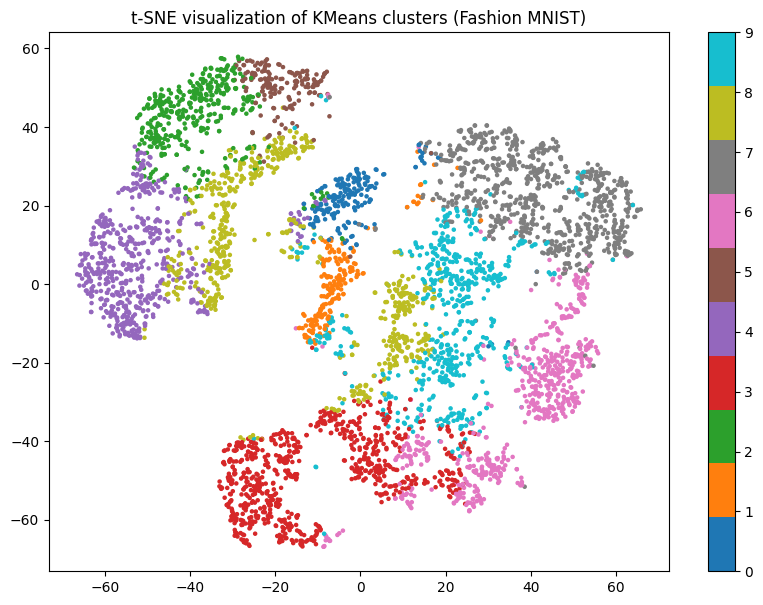

In [75]:


from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca[:5000])   # use subset for speed
clusters_subset = clusters[:5000]

plt.figure(figsize=(10,7))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_subset, cmap="tab10", s=5)
plt.colorbar()
plt.title("t-SNE visualization of KMeans clusters (Fashion MNIST)")
plt.show()

# DBSCAN 

In [92]:
dbscan = DBSCAN(eps=0.5, min_samples=5, metric='cosine')  # eps may need tuning

clusters_db = dbscan.fit_predict(X_pca)

# DBSCAN may create noise points labeled -1, exclude them for metrics
mask = clusters_db != -1

ari_db = adjusted_rand_score(y_train[mask], clusters_db[mask])
nmi_db = normalized_mutual_info_score(y_train[mask], clusters_db[mask])
# sil_db = silhouette_score(X_pca[mask], clusters_db[mask])

In [93]:
n_clusters = len(np.unique(clusters_db[mask]))
print("Number of clusters (excluding noise):", n_clusters)

Number of clusters (excluding noise): 1


In [94]:
print("Adjusted Rand Index (ARI):", ari_db)
print("Normalized Mutual Info (NMI):", nmi_db)


Adjusted Rand Index (ARI): 0.0
Normalized Mutual Info (NMI): 0.0


In [ ]:
# DBSCAN is not working here because of dataset nature like
# high dimension 
# overlapping clusters
# cluster shapes 

# Agglomerative Clustering

In [113]:
pca = PCA(n_components=20)

X_pca = pca.fit_transform(X_train)

In [114]:

agglo = AgglomerativeClustering(n_clusters=10)
clusters_agglo = agglo.fit_predict(X_pca)

ari_a = adjusted_rand_score(y_train, clusters_agglo)
nmi_a = normalized_mutual_info_score(y_train, clusters_agglo)
sil_a = silhouette_score(X_pca, clusters_agglo)

In [116]:
print("Adjusted Rand Index (ARI):", ari_a)
print("Normalized Mutual Info (NMI):", nmi_a)
print("Silhouette Score:", sil_a)

Adjusted Rand Index (ARI): 0.39738857661036797
Normalized Mutual Info (NMI): 0.5510727684411579
Silhouette Score: 0.197528304226423


In [ ]:
#
# ARI	        0.397	Moderate agreement with true labels; your clusters are starting to align with 
#                        real classes.
# NMI	        0.551	Fairly strong shared information; clustering captures over half of the 
#                      structure in labels.
# Silhouette	0.198	Weak but meaningful cluster separation; points are slightly closer to 
#                       their own cluster than to others.

In [117]:
n_samples = 100

X_sample = X_train[:n_samples]

pca = PCA(n_components=70, random_state=42)
X_pca_sample = pca.fit_transform(X_sample)

# -----------------------
# Compute linkage matrix
# -----------------------
Z = linkage(X_pca_sample, method='ward') 


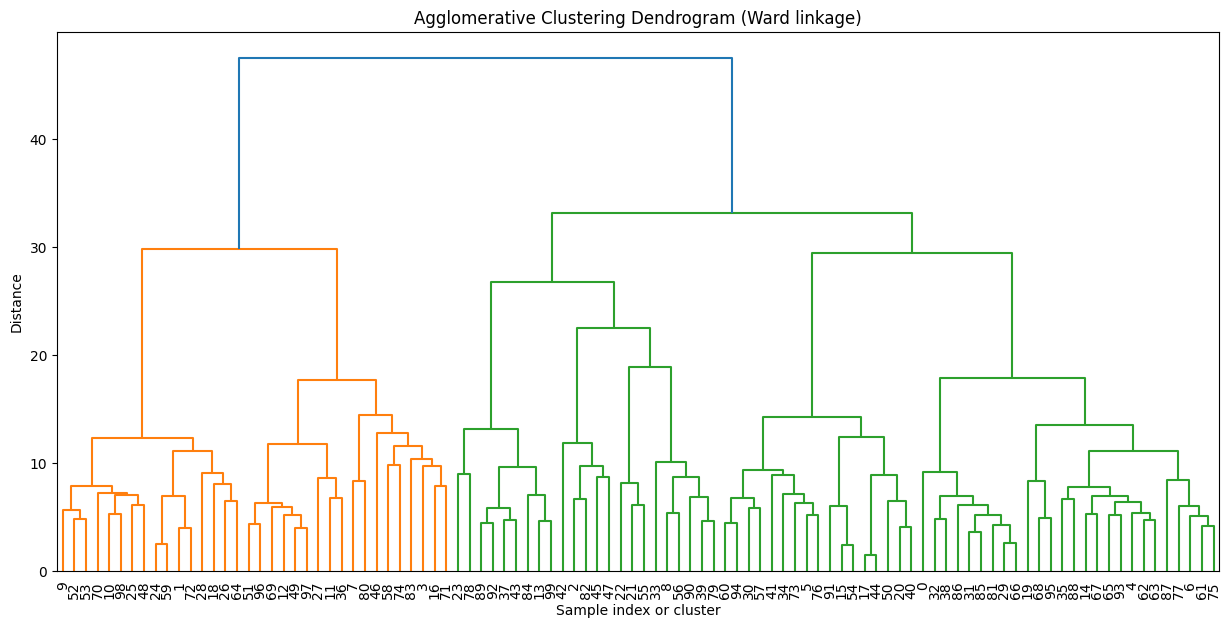

In [118]:
# -----------------------
# Plot dendrogram
# -----------------------
plt.figure(figsize=(15, 7))
dendrogram(
    Z,
    truncate_mode='level',  # show only last p merged clusters
    p=30,                   # adjust for readability
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title("Agglomerative Clustering Dendrogram (Ward linkage)")
plt.xlabel("Sample index or cluster")
plt.ylabel("Distance")
plt.show()

In [124]:
results = [
    
    # Unsupervised 
    {
        "Method": "KMeans",
        "ARI": 0.3498370201302381,
        "NMI": 0.5068642361584237,
        "Silhouette": 0.17265842606531395,
        "Clusters": 10,
        
    },
    {
        "Method": "DBSCAN",
        "ARI": 0.0,
        "NMI": 0.0,
        # "Silhouette": np.nan,
        "Clusters": 1,
        
    },
    {
        "Method": "Agglomerative",
        "ARI": 0.397,
        "NMI": 0.551,
        "Silhouette": 0.198,
        "Clusters": 10,
        
    },
    # supervised 
    {
        "Method": "KNN (PCA)",
        "Accuracy": 0.86,                 
        "Weighted_F1": 0.86                
    }
]